# Fase 1: Análisis Exploratorio de Datos (EDA)
**Curso:** Inteligencia Artificial I
**Proyecto:** Predicción de Abandono Escenario - Telco Customer Churn (ProyectoB_SPAC)

---

## 1. Introducción
El Análisis Exploratorio de Datos (EDA) es una etapa crítica en el flujo de trabajo de Ciencia de Datos e Inteligencia Artificial. Su objetivo principal es comprender la estructura de los datos, identificar anomalías, limpiar registros inconsistentes y seleccionar las características óptimas para el entrenamiento de modelos predictivos (Redes Neuronales Artificiales - ANN).

Para garantizar un código limpio, modular y mantenible, toda la lógica de ingeniería de características se ha encapsulado en la clase orientada a objetos `ProcesadorEDA`.

### Componentes Clave de la Clase:
1. **Encapsulamiento:** Uso de atributos privados (`self.__DF_data`, `self.__num_filas`, `self.__num_columnas`) controlados mediante decoradores `@property` (getters y setters).
2. **Pipeline de Sanitización:** Métodos específicos para limpiar strings, gestionar nulos de forma segura y remover registros duplicados.
3. **Ingeniería de Atributos:** Transformación binaria del target mediante mapeos de Pandas y codificación de variables categóricas con `OneHotEncoder` de Scikit-Learn.
4. **Análisis Estadístico Avanzado:** Selección automática de variables predictoras mediante el Coeficiente de Correlación de Pearson.

In [37]:
import os
import sys
import pandas as pd

# Añadimos la raíz del proyecto al path del sistema para importar nuestro archivo modular
sys.path.append(os.path.abspath(os.path.join('..')))
from eda.procesador_eda import ProcesadorEDA

# 1. Definir la ruta del dataset original (Raw) basado en la estructura del proyecto
ruta_raw = os.path.join('..', 'data', 'raw', 'raw', 'WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Validar existencia y cargar el DataFrame base
if os.path.exists(ruta_raw):
    df_clientes = pd.read_csv(ruta_raw)
    print(f"✅ Dataset cargado correctamente. Dimensiones iniciales: {df_clientes.shape}")

    # 3. Instanciar el objeto principal de nuestra clase
    analisis_churn = ProcesadorEDA(DF_data=df_clientes)
else:
    print(f"❌ Error: No se encontró el archivo en la ruta especificada: {ruta_raw}")

✅ Dataset cargado correctamente. Dimensiones iniciales: (7043, 21)


## 2. Inspección Inicial y EDA
En este bloque ejecutamos el diagnóstico de tipos de datos, estadísticas básicas y aplicamos tratamientos correctivos para erradicar inconsistencias en formatos de texto, datos nulos o registros duplicados.

In [39]:
# Diagnóstico general (info, head y describe)
analisis_churn.informacion_data()

print("\n" + "="*50 + "\n")

# Limpieza de codificación UTF-8 en strings
analisis_churn.limpiar_texto()

# Gestión de valores faltantes (Eliminación de nulos)
analisis_churn.gestionar_datos_nulos()

# Control de registros duplicados (Muestra el reporte sin borrar físicamente)
analisis_churn.gestionar_datos_duplicados(eliminar=False)

Información general del dataset
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  704

## 3. Preparación de Variables para Modelos de Inteligencia Artificial
Las Redes Neuronales de Keras requieren matrices numéricas continuas o discretas. En esta sección realizamos dos procesos fundamentales:
1. **Mapeo Binario:** Convertir el target comercial `'Churn'` (`Yes`/`No`) a formato binario estructurado ($1$ / $0$).
2. **One-Hot Encoding:** Convertir variables categóricas de múltiples estados en columnas binarias independientes (dummies) utilizando `drop='if_binary'` para prevenir la multicolinealidad.

--- Transformando Variable Objetivo (Churn) ---
✅ Transformación de 'Churn' completada con éxito (Yes -> 1, No -> 0).

--- Conteo de clases en la variable 'Churn' ---
Clase [0] -> No (Permanencia): 5174 registros
Clase [1] -> Yes (Abandono): 1869 registros




[EDA] Generando gráfico de distribución para la variable 'Churn'...


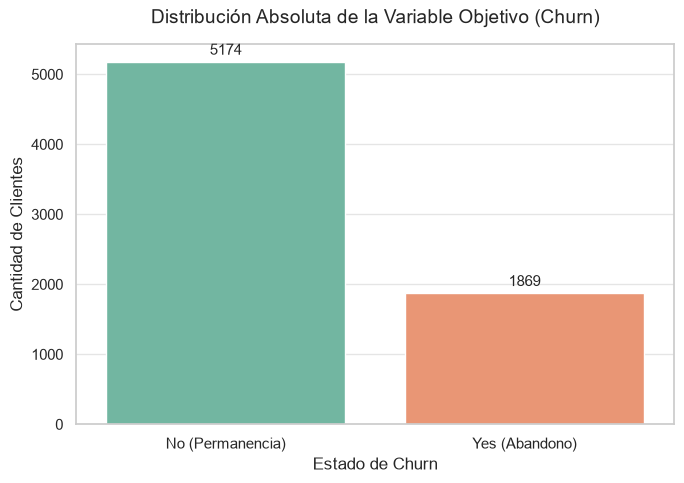

[EDA] Gráfico de distribución generado con éxito.


--- Aplicando One-Hot Encoding Optimizado ---
Variables seleccionadas para codificación: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
One-Hot Encoding completado con éxito.
Nuevo tamaño del dataset: 7043 filas x 42 columnas (Estructura compacta).



One-Hot Encoding


--- Primeros 5 registros del Dataset Actualizado One-Hot Encoding ---
   customerID  SeniorCitizen  tenure  MonthlyCharges TotalCharges  Churn  gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  MultipleLines_No  MultipleLines_No phone service  MultipleLines_Yes  InternetService_DSL  InternetService_Fiber optic  InternetService_No  OnlineSecurity_No  OnlineSecurity_No internet service  OnlineSecurity_Yes  OnlineBackup_No  OnlineBackup_No internet service  OnlineBackup_Ye

In [41]:
# Transformar variable objetivo
analisis_churn.transformar_target_churn()

# Graficar la distribución base del Churn (Ejecutar antes de recortar el dataset)
analisis_churn.graficar_distribucion_churn()

print("\n" + "="*50 + "\n")

# Aplicar One-Hot Encoding optimizado a variables de texto con baja cardinalidad
df_procesado = analisis_churn.aplicar_one_hot_encoding()

## 4. Análisis de Correlación de Pearson y Métricas del Negocio
Medimos la fuerza de asociación lineal entre las variables predictoras procesadas y nuestra variable objetivo. Esto nos permite identificar qué factores (servicios, contratos, cargos financieros) incrementan o mitigan el riesgo de fuga de los clientes.

--- Calculando Correlaciones Fuertes con Churn (Ordenadas de Mayor a Menor) ---

Variables más correlacionadas con el Churn (Abandono):
Variable                                      | Coeficiente de Correlación
---------------------------------------------------------------------------
Contract_Month-to-month                       |                   0.4051
OnlineSecurity_No                             |                   0.3426
TechSupport_No                                |                   0.3373
InternetService_Fiber optic                   |                   0.3080
PaymentMethod_Electronic check                |                   0.3019
OnlineBackup_No                               |                   0.2680
DeviceProtection_No                           |                   0.2525
MonthlyCharges                                |                   0.1934
PaperlessBilling_Yes                          |                   0.1918
SeniorCitizen                                 |         

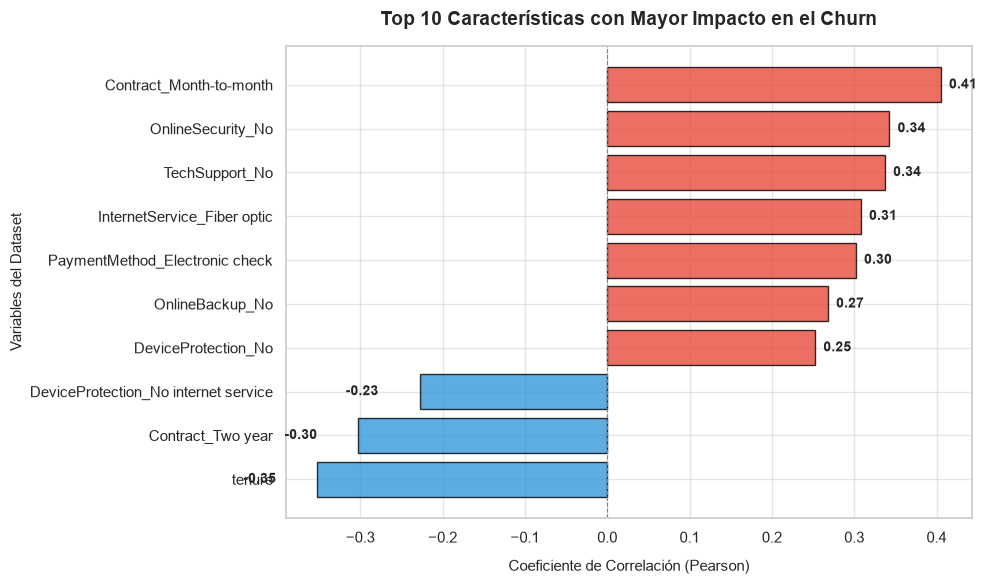

In [43]:
# Mostrar coeficientes ordenados de mayor a menor en texto
correlaciones_fuertes = analisis_churn.obtener_correlaciones_fuertes(umbral=0.1)

# Desplegar el top de características con impacto visual (Barras rojas/azules)
analisis_churn.grafico_correlaciones_churn(target='Churn', top_n=10)

## 5. Segmentación del Conocimiento y Exportación de Archivos
Para alimentar de forma independiente a nuestros notebooks de modelos (`02_ANN_Modelo1.ipynb` y `03_ANN_Modelo2.ipynb`), la clase creará dos archivos diferenciados en la alfombra de datos procesados (`src/eda/processed/`):

1. **Dataset Reducido Estándar (`telco_churn_reducido.csv`):** Conserva variables de alta correlación incluyendo comportamientos financieros (`MonthlyCharges`, `TotalCharges`) e infraestructura de red (`InternetService`).
2. **Dataset Específico para el Modelo Final (`telco_churn_reducido_modelo.csv`):** Remueve explícitamente cargos y servicios de internet para evaluar el impacto puro de variables contractuales y demográficas en la red neuronal.

--- Generando dataset reducido basado en correlación (Umbral: 0.25) ---
✅ Variables seleccionadas finales ordenadas (14):
['Churn', 'gender_Male', 'tenure', 'MonthlyCharges', 'TotalCharges', 'InternetService_No', 'InternetService_DSL', 'InternetService_Fiber optic', 'OnlineSecurity_No', 'OnlineBackup_No', 'DeviceProtection_No', 'TechSupport_No', 'Contract_Month-to-month', 'Contract_Two year']

✅ Dataset reducido creado correctamente
Nuevo tamaño: 7043 filas x 14 columnas
✅ El dataset reducido se ha guardado en: C:\Users\casa\Documents\IA I Cuatrimestre 2026\Proyectos\ProyectoB_SPAC\notebooks\src\eda\processed\telco_churn_reducido.csv

--- Primeros 5 registros del Dataset Reducido (Columnas Ordenadas) ---
   Churn  gender_Male  tenure  MonthlyCharges TotalCharges  InternetService_No  InternetService_DSL  InternetService_Fiber optic  OnlineSecurity_No  OnlineBackup_No  DeviceProtection_No  TechSupport_No  Contract_Month-to-month  Contract_Two year
0      0          0.0       1           

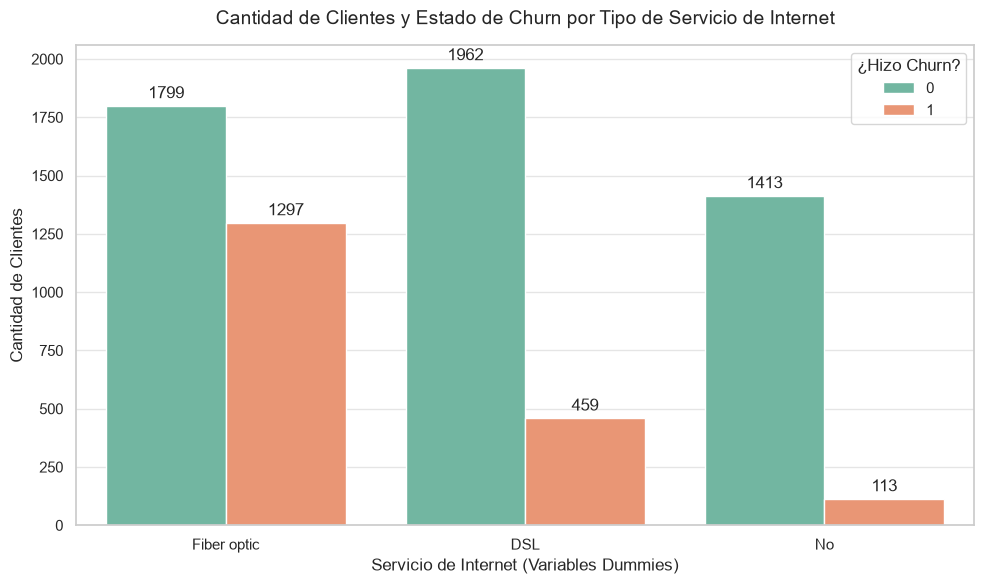

[EDA] Gráfico de barras generado con éxito desde las variables dummies.

[EDA] Generando boxplot de Género y Cargos Totales vs Churn...


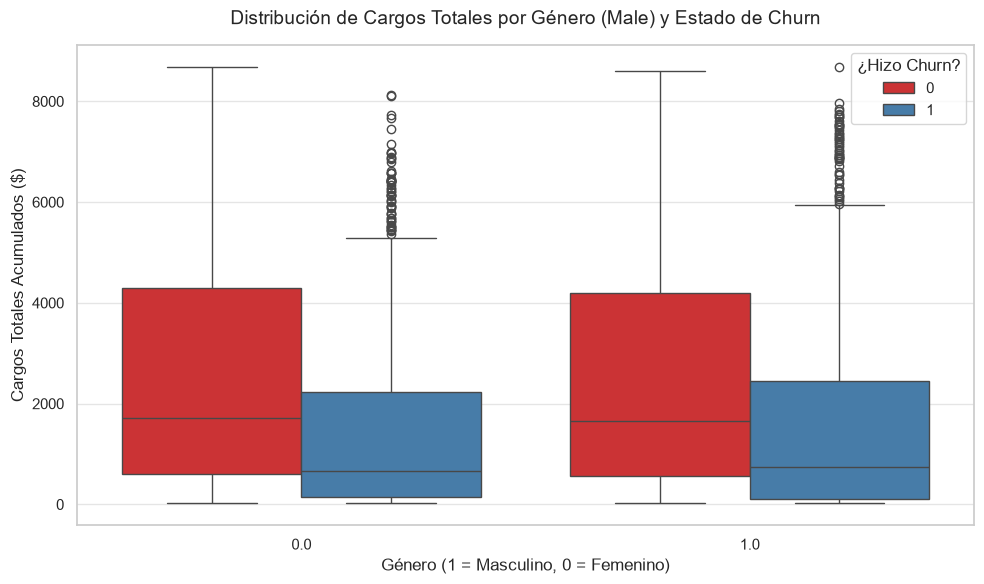

[EDA] Gráfico de Cargos Totales generado con éxito.



--- Generando dataset específico para el modelo (Umbral: 0.25) ---
✅ Variables seleccionadas para el modelo (8):
['Churn', 'gender_Male', 'OnlineSecurity_No', 'OnlineBackup_No', 'DeviceProtection_No', 'TechSupport_No', 'Contract_Month-to-month', 'Contract_Two year']

✅ DataFrame 'self.__DF_reducido_modelo' creado correctamente.
Tamaño: 7043 filas x 8 columnas
✅ El nuevo archivo se ha guardado en: C:\Users\casa\Documents\IA I Cuatrimestre 2026\Proyectos\ProyectoB_SPAC\notebooks\src\eda\processed\telco_churn_reducido_modelo.csv

--- Primeros 5 registros del Nuevo Dataset ---
   Churn  gender_Male  OnlineSecurity_No  OnlineBackup_No  DeviceProtection_No  TechSupport_No  Contract_Month-to-month  Contract_Two year
0      0          0.0                1.0              0.0                  1.0             1.0                      1.0                0.0
1      0          1.0                0.0              1.0                  0.0         

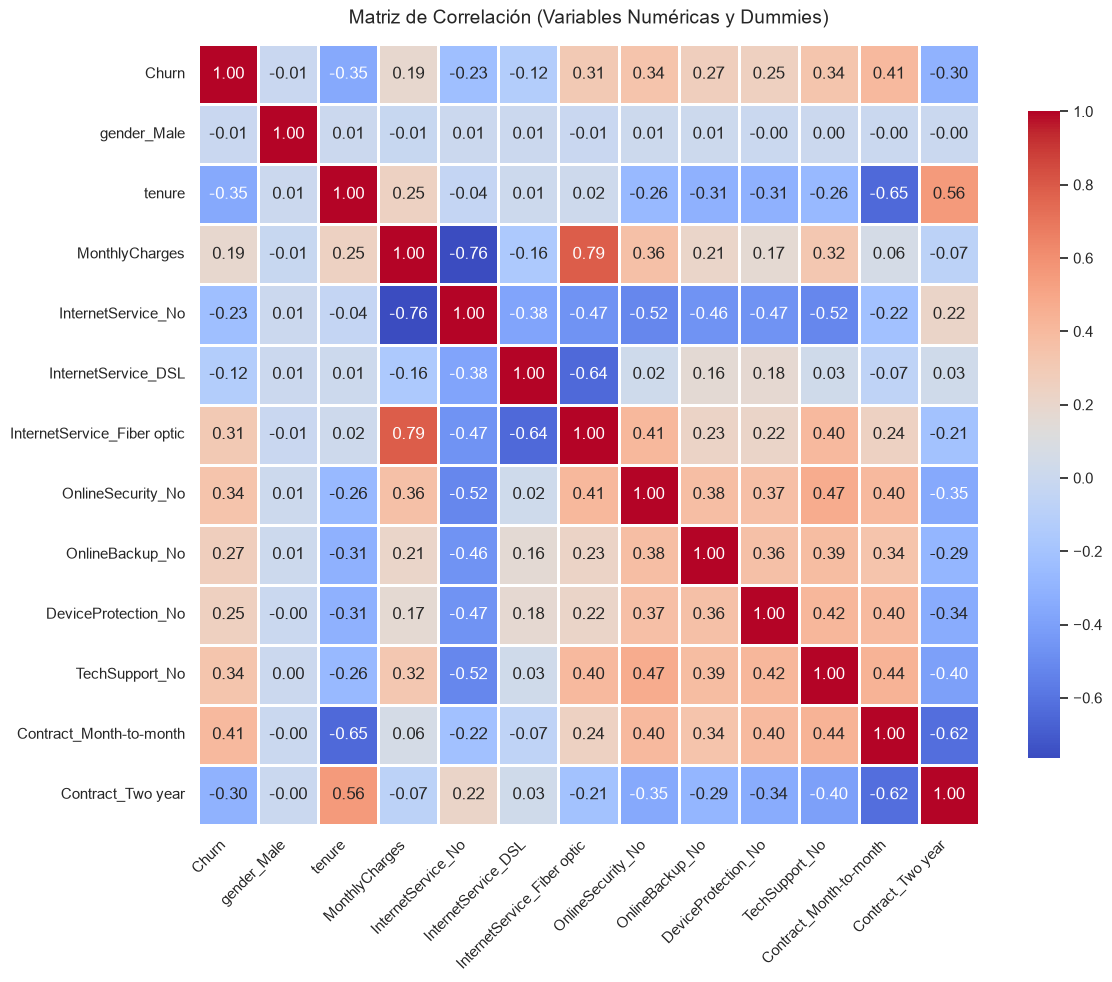

[EDA] Matriz de correlación desplegada con éxito.


,Churn,gender_Male,tenure,MonthlyCharges,InternetService_No,InternetService_DSL,InternetService_Fiber optic,OnlineSecurity_No,OnlineBackup_No,DeviceProtection_No,TechSupport_No,Contract_Month-to-month,Contract_Two year
Churn,1.000000,-0.008612,-0.352229,0.193356,-0.227890,-0.124214,0.308020,0.342637,0.268005,0.252481,0.337281,0.405103,-0.302253
gender_Male,-0.008612,1.000000,0.005106,-0.014569,0.006026,0.006568,-0.011286,0.010429,0.008191,-0.002988,0.003397,-0.003386,-0.003695
tenure,-0.352229,0.005106,1.000000,0.247900,-0.039062,0.013274,0.019720,-0.263746,-0.312694,-0.312740,-0.262143,-0.645561,0.558533
MonthlyCharges,0.193356,-0.014569,0.247900,1.000000,-0.763557,-0.160189,0.787066,0.360898,0.210753,0.171836,0.322076,0.060165,-0.074681
InternetService_No,-0.227890,0.006026,-0.039062,-0.763557,1.000000,-0.380635,-0.465793,-0.522429,-0.464720,-0.465658,-0.518733,-0.218639,0.218278
InternetService_DSL,-0.124214,0.006568,0.013274,-0.160189,-0.380635,1.000000,-0.640987,0.023066,0.164783,0.175942,0.029402,-0.065509,0.031714
InternetService_Fiber optic,0.308020,-0.011286,0.019720,0.787066,-0.465793,-0.640987,1.000000,0.411561,0.228047,0.218148,0.402430,0.244164,-0.211526
OnlineSecurity_No,0.342637,0.010429,-0.263746,0.360898,-0.522429,0.023066,0.411561,1.000000,0.378468,0.371808,0.470359,0.403255,-0.353300
OnlineBackup_No,0.268005,0.008191,-0.312694,0.210753,-0.464720,0.164783,0.228047,0.378468,1.000000,0.361488,0.385341,0.338796,-0.287944
DeviceProtection_No,0.252481,-0.002988,-0.312740,0.171836,-0.465658,0.175942,0.218148,0.371808,0.361488,1.000000,0.419892,0.397454,-0.339190


In [45]:
# Generar y guardar Dataset Reducido Estándar
df_reducido = analisis_churn.generar_dataset_reducido(target='Churn', umbral=0.25)

# Visualizar Boxplots y Distribuciones con base en el dataset reducido actual
analisis_churn.graficar_boxplot_internet_churn()
analisis_churn.graficar_boxplot_genero_cargos_churn()

print("\n" + "="*50 + "\n")

# Generar y guardar el Dataset Específico de Arquitectura Final para el Modelo
df_modelo_final = analisis_churn.generar_dataset_final_modelo(target='Churn', umbral=0.25)

print("\n" + "="*50 + "\n")

# Mostrar mapa de calor de correlaciones del dataset final filtrado
analisis_churn.eda_matriz_correlacion()

## 6. Conclusiones del EDA listo para Modelado
* El conjunto de datos ha quedado balanceado en tipos de datos estrictamente numéricos (`int64` y `float64`), listos para operaciones matriciales.
* Se eliminaron filas con nulos ocultos en variables críticas como cargos acumulados.
* Los archivos correspondientes han sido persistidos físicamente en disco. Estamos listos para proceder al diseño de la Red Neuronal Artificial en el Notebook **`02_ANN_Modelo1.ipynb`**.